# Results

In [5]:
from collections import defaultdict
from ast import literal_eval  # to convert string list ↦ python list
import random

# CORE FUNCTION
def sample_next_token(prob_dicts, sequence, n):
	prefix = ()
	# Get the current prefix (last n-1 words)
	if n > 1:
		prefix = tuple(sequence[-(n-1):])

	# In the probability dictionary, get possible next tokens for the given prefix
	next_tokens = prob_dicts[n].get(prefix, {})
	# If no next tokens found, back off to (n-1)-gram model
	if next_tokens == {}:
		return sample_next_token(prob_dicts, sequence, n-1)				# RECURSION: try with n-1-gram
	
	words = list(next_tokens.keys())
	probs = list(next_tokens.values())
	
	next_token = random.choices(words, weights=probs, k=1)[0]
	print(f"Current n: {n}, Current prefix: {prefix}, Next token: {next_token} ")
	return next_token

## Task 1: Generate Parragraphs

In [6]:
# TASK 1
def generative_ngram(n, mt, prob_json, nr_outputs=1):
	# Create a list for probability dictionaries
	prob_dicts = [{}]

	for k in range(1, n+1):
		prob_dict = {}
		for prefix_str, next_tokens in prob_json[k].items():
			prefix = literal_eval(prefix_str)
			prob_dict[prefix] = {}
			for token, prob in next_tokens.items():
				prob_dict[prefix][token] = prob
		prob_dicts.append(prob_dict)

	# Initialize output list
	output = [""] * nr_outputs

	for i in range(nr_outputs):
		print("NEW OUTPUT IN PROGRESS")
		if mt == "word":
			# Generate a sentence starting from <s> and ending at </s> based on the probability dictionary
			sequence = ["<s>"]
			
			# As long as the end symbol </s> is not reached, keep sampling the next word
			while sequence[-1] != "</s>":
				next_word = sample_next_token(prob_dicts, sequence, n)
				sequence.append(next_word)
			
			output[i] = " ".join(sequence)		# Convert list of generated words to a single string using space as separator

		else:
			# Generate a character sequence ending at ".", "!" or "?" based on the probability dictionary
			sequence = [""]
			# As long as none of the end symbols is reached, keep sampling the next character
			while sequence[-1] != "." and sequence[-1] != "!" and sequence[-1] != "?":
				next_char = sample_next_token(prob_dicts, sequence, n)
				sequence.append(next_char)
			
			output[i] = "".join(sequence)		# Convert list of generated characters to a single string

	return output

## Task 2: Complete Sentences

In [7]:
# TASK 2
def complete_sentence(sentence, n, prob_json):
	# Create a list for probability dictionaries
	prob_dicts = [{}]

	for k in range(1, n+1):
		prob_dict = {}
		for prefix_str, next_tokens in prob_json[k].items():
			prefix = literal_eval(prefix_str)
			prob_dict[prefix] = {}
			for token, prob in next_tokens.items():
				prob_dict[prefix][token] = prob
		prob_dicts.append(prob_dict)

	# Initialize output sequence with the given sentence start
	sequence = sentence.copy()
			
	# As long as the end symbol ".", "!" or "?" is not reached, keep sampling the next word
	while sequence[-1] != "." and sequence[-1] != "!" and sequence[-1] != "?":
		next_word = sample_next_token(prob_dicts, sequence, n)
		sequence.append(next_word)
		
	output = " ".join(sequence)		# Convert list of generated words to a single string using space as separator
	return output

## Model based on Testing Data

In [9]:
import os
import json

N = {1, 2, 3, 4, 5}													# Fallback strategy: if a prefix does not exist in N-gram dictionary, back off to N-1-gram model
modeltype = {"word", "character"}										# "word", "character"
categories = {"business", "entertainment", "politics", "sport", "tech", "all"}	# "business", "entertainment", "politics", "sport", "tech", "all"

sourcefolder = f"./../Probability_NGrams/Testing/"
targetfolder = f"./../Results/Task1_GeneratedSequences/Testing/"

# Number of sequences to be generated
nr_outputs = 1

for category in categories:
	for mt in modeltype:
		for n in N:
			print(f"NEW N-GRAM IN PROGRESS: {mt}-{n}-gram with category {category}")
			
			# Initialize list of dictionaries
			prob_json = [""]  # Start with a dummy entry for 0-grams to align indices

			# Read in JSON probability file(s) and catch non-existing files
			for k in range(1, n+1):
				json_path = f"{sourcefolder}{mt}_{k}grams_{category}_probability.json"
				if not os.path.exists(json_path):
					print(f"Skipping (file not found): {json_path}")
					continue
			
				with open(json_path, "r", encoding="utf-8") as f:
					#print(f"Loading: {json_path}")
					dictionary = json.load(f)
					prob_json.append(dictionary)

			# Let n-gram model create sequences
			output = generative_ngram(n, mt, prob_json, nr_outputs)

			# Make the list of outputs into a single string with line breaks
			output = "\n\n".join(output)

			# Save outputs as TXT file
			output_path = f"{targetfolder}{category}_{mt}_{n}grams_generated.txt"
			with open(output_path, "w", encoding="utf-8") as f:
				f.write(str(output))

NEW N-GRAM IN PROGRESS: word-1-gram with category politics
NEW OUTPUT IN PROGRESS
Current n: 1, Current prefix: (), Next token: liberty 
Current n: 1, Current prefix: (), Next token: Lord 
Current n: 1, Current prefix: (), Next token: of 
Current n: 1, Current prefix: (), Next token: ID 
Current n: 1, Current prefix: (), Next token: had 
Current n: 1, Current prefix: (), Next token: society 
Current n: 1, Current prefix: (), Next token: Today 
Current n: 1, Current prefix: (), Next token: Plans 
Current n: 1, Current prefix: (), Next token: departure 
Current n: 1, Current prefix: (), Next token: pleas 
Current n: 1, Current prefix: (), Next token: a 
Current n: 1, Current prefix: (), Next token: passport 
Current n: 1, Current prefix: (), Next token: to 
Current n: 1, Current prefix: (), Next token: and 
Current n: 1, Current prefix: (), Next token: still 
Current n: 1, Current prefix: (), Next token: bill 
Current n: 1, Current prefix: (), Next token: real 
Current n: 1, Current pref

In [10]:
import json
import os
import json

N = {1, 2, 3, 4, 5}													# Fallback strategy: if a prefix does not exist in N-gram dictionary, back off to N-1-gram model
categories = {"business", "entertainment", "politics", "sport", "tech", "all"}	# "business", "entertainment", "politics", "sport", "tech", "all"
	
sourcefolder = f"./../Probability_NGrams/Testing/"
targetfolder = f"./../Results/Task2_SequenceCompletion/Testing/"

nr_outputs = 5			# Number of completion suggestions to be generated
nr_words = 1			# Number of words to inserted for <gap>

gap_sentences = ( 
    ["The", "economy", "has", "<gap>", "this", "year", "."],
    ["The", "finance", "minister", "said", "the", "<gap>", ",", "which", "had", "<gap>", "intense", "<gap>", "from","several","EU", "members", ",", "would", "be", "<gap>", "before", "the", "final", "vote", "next", "month", "."],
    ["After", "months", "of", "<gap>", ",", "the", "agreement", "between", "the", "two", "companies", "was", "finally", "<gap>", ",", "paving", "the", "way", "for", "joint", "<gap>", "into", "renewable", "energy", "technologies", "."],
    ["Scientists", "reported", "that", "the", "newly", "<gap>", "exoplanet", "shows", "<gap>", "of", "an", "atmosphere", "rich", "in", "methane", ",", "a", "finding", "that", "could", "<gap>", "current", "models", "of", "planetary", "formation", "."]
)

sentences = ( 
    ["The", "economy", "has"],
    ["The", "finance", "minister", "said"],
    ["After", "months", "of"],
    ["Scientists", "reported", "that"]
)

for category in categories:
	for n in N:
		print(f"NEW N-GRAM IN PROGRESS: {n}-gram with category {category}")
	
		# Initialize list of dictionaries
		prob_json = [""]  # Start with a dummy entry for 0-grams to align indices

		# Read in JSON probability file(s) and catch non-existing files
		for k in range(1, n+1):
			json_path = f"{sourcefolder}word_{k}grams_{category}_probability.json"
			if not os.path.exists(json_path):
				print(f"Skipping (file not found): {json_path}")
				continue
			
			with open(json_path, "r", encoding="utf-8") as f:
				#print(f"Loading: {json_path}")
				dictionary = json.load(f)
				prob_json.append(dictionary)
		
		outputs = []
		for sentence in sentences:
			print("NEW SENTENCE IN PROGRESS")
			sentence_outputs = []
			for j in range(nr_outputs):
				print("NEW COMPLETION IN PROGRESS")
				#filled = fill_gaps(sentence, n, prob_json, nr_words)
				completed = complete_sentence(sentence, n, prob_json)
				sentence_outputs.append(completed)
					
			# Convert the list of suggestions for one sentence completion into a single string with line breaks
			outputs.append("\n".join(sentence_outputs))

		# Convert the list of single sentence solution sets into a single string with double line breaks
		output = "\n\n".join(outputs)

		# Save output as TXT file
		output_path = f"{targetfolder}{category}_word_{n}grams_completions.txt"
		with open(output_path, "w", encoding="utf-8") as f:
			f.write(str(output))

NEW N-GRAM IN PROGRESS: 1-gram with category politics
NEW SENTENCE IN PROGRESS
NEW COMPLETION IN PROGRESS
Current n: 1, Current prefix: (), Next token: a 
Current n: 1, Current prefix: (), Next token: claiming 
Current n: 1, Current prefix: (), Next token: at 
Current n: 1, Current prefix: (), Next token: could 
Current n: 1, Current prefix: (), Next token: said 
Current n: 1, Current prefix: (), Next token: have 
Current n: 1, Current prefix: (), Next token: What 
Current n: 1, Current prefix: (), Next token: cards 
Current n: 1, Current prefix: (), Next token: pause 
Current n: 1, Current prefix: (), Next token: be 
Current n: 1, Current prefix: (), Next token: similar 
Current n: 1, Current prefix: (), Next token: cards 
Current n: 1, Current prefix: (), Next token: had 
Current n: 1, Current prefix: (), Next token: legislation 
Current n: 1, Current prefix: (), Next token: appropriate 
Current n: 1, Current prefix: (), Next token: illegal 
Current n: 1, Current prefix: (), Next tok

# Viewing Results

## Perplexity

Metric that measures the uncertainty of a model's predictions. Specifically, in language models, it quantifies how well the model predicts the next word in a sequence. When a model makes a prediction, it assigns probabilities to possible next words.

Let $w_1, w_2, \dots, w_T$ be a sequence of words in the test set.
The perplexity of an $n$-gram language model is defined as:

$$
\text{Perplexity}
= \exp\left(
-\frac{1}{T}
\sum_{t=1}^{T}
\log P\!\left(
w_t \mid w_{t-(n-1)}, \dots, w_{t-1}
\right)
\right)
$$

GeeksforGeeks. (2025, July 23). Perplexity for LLM evaluation. https://www.geeksforgeeks.org/nlp/perplexity-for-llm-evaluation/ 

**Where:**

- $T$ is the total number of tokens (words) in the sentence.

- $w_t$ denotes the word at position $t$ in the sentence.

- $n$ is the order of the N-gram model (e.g., $n = 1$ for a unigram model, $n = 2$ for a bigram model).

- $(w_{t-n+1}, \ldots, w_{t-1})$ represents the $(n-1)$-word context preceding the word $w_t$.

- $P(w_t \mid w_{t-n+1}, \ldots, w_{t-1})$ is the conditional probability assigned by the N-gram model to the word $w_t$ given its preceding context.

- $\sum_{t=1}^{T}$ indicates that the log-probabilities are summed over all word positions in the sentence.

- $\log(\cdot)$ is used to convert the product of probabilities into a sum, which improves numerical stability and interpretability.


In [17]:
import json
from math import log, exp 
import pandas as pd

def compute_perplexity(test_csv, prob_dicts, n, epsilon=1e-12):
    df = pd.read_csv(test_csv)
    log_prob_sum = 0.0
    T = 0

    model = prob_dicts[n]

    for ngram_str in df["N-gram"]:
        ngram = eval(ngram_str)  # ['w1','w2',...]
        target = ngram[-1]

        if n == 1:
            context = "()"
        else:
            context = str(tuple(ngram[:-1]))

        prob = model.get(context, {}).get(target, epsilon)

        log_prob_sum += log(prob)
        T += 1

    return exp(-log_prob_sum / T)


def load_probability_model(path):
    with open(path, "r", encoding="utf-8") as f:
        model = json.load(f)
    return model

In [26]:
modeltype = "word"									# "word", "character"
category ="all"	# "business", "entertainment", "politics", "sport", "tech", "all"

prob_dicts = {}
for n in [1, 2, 3, 4, 5]:
    path = f"./../Probability_NGrams/Testing/{modeltype}_{n}grams_{category}_probability.json"
    prob_dicts[n] = load_probability_model(path)

N = [1, 2, 3, 4, 5]
perplexities = []

for n in N:
    test_file = f"./../Dataset_NGrams/bbc_word_{n}grams_test.csv"
    ppl = compute_perplexity(test_file, prob_dicts, n)
    perplexities.append(ppl)

perplexities

[472.4735902564866,
 5.647520761314182,
 1.2919436154341504,
 1.0302428942943422,
 1.0090808768098003]

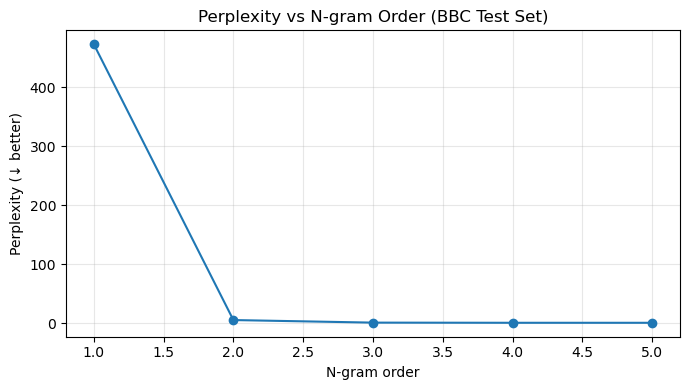

In [27]:
import matplotlib.pyplot as plt

N = [1, 2, 3, 4, 5]

plt.figure(figsize=(7, 4))
plt.plot(N, perplexities, marker="o")
plt.xlabel("N-gram order")
plt.ylabel("Perplexity (↓ better)")
plt.title("Perplexity vs N-gram Order (BBC Test Set)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

For each N-gram order, we run the model on testing sentences and measure how often the generated continuation matches the true continuation in the test set.